# Performance journalière sur 12 mois — Comparaison par cohorte

## Objectif
Visualiser et comparer la **performance cumulée quotidienne** des IPO sur leurs **12 premiers mois de cotation**.

## Cohortes
- **2019-2021** : marché pré-Covid et choc pandémique
- **2022-2024** : période de hausse des taux et normalisation

## Méthodologie
1. Téléchargement des prix quotidiens via `yfinance` (avec cache local)
2. Calcul du rendement cumulé : `(Prix_j / Prix_ouverture_IPO) - 1`
3. Alignement sur le **jour de trading** (J=1, 2, ..., 252)
4. Agrégation par cohorte : médiane, moyenne, IQR
5. Visualisation comparative

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import os
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (14, 6), "figure.dpi": 120})

COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}
CACHE_PATH = Path("data/daily_returns_cache.csv")
N_TRADING_DAYS = 365  # ~12 mois

print("Imports OK")

Imports OK


In [2]:
# ── 1. Chargement des données de base ──────────────────────────────────────
df_base = pd.read_excel("data/dataset_complet_filled.xlsx")
df_base["ipo_date"] = pd.to_datetime(df_base["ipo_date"])

df_base = df_base[df_base["year"].between(2019, 2024)].copy()
df_base = df_base.dropna(subset=["ipo_date", "open_px"])
df_base = df_base[df_base["open_px"] > 0].copy()

# Attribution des cohortes
df_base["cohort"] = np.where(df_base["year"].between(2019, 2021), "2019-2021", "2022-2024")

print(f"Total IPOs retenus : {len(df_base)}")
print(df_base.groupby(["year", "cohort"]).size().to_string())

Total IPOs retenus : 782
year  cohort   
2019  2019-2021    112
2020  2019-2021    143
2021  2019-2021    163
2022  2022-2024     69
2023  2022-2024     98
2024  2022-2024    197


In [9]:
df_base['ipo_date'].iloc[:5]
df_base['ipo_date'].dtype


dtype('<M8[us]')

In [6]:
# ── 2. Téléchargement des prix quotidiens (avec cache) ─────────────────────
# Le cache évite de re-télécharger à chaque exécution (~5-10 min la 1ère fois)


if CACHE_PATH.exists():
    print(f"✓ Cache trouvé : {CACHE_PATH}")
    df_daily = pd.read_csv(CACHE_PATH)
    print(f"  {len(df_daily):,} lignes | {df_daily['ticker'].nunique()} tickers")
else:
    print("Téléchargement des données quotidiennes (première exécution)...")
    print(f"Nombre de tickers à traiter : {len(df_base)}")
    print("Cela peut prendre 5-15 minutes...\n")

    records = []
    errors = []

    for i, row in df_base.iterrows():
        ticker    = row["ticker"]
        ipo_date  = row["ipo_date"]
        cohort    = row["cohort"]
        year      = row["year"]
        open_px   = row["open_px"]

        # Fenêtre : IPO date → IPO date + 14 mois (buffer)
        end_date = ipo_date + pd.DateOffset(days=430)

        try:
            hist = yf.download(
                ticker,
                start=ipo_date.strftime("%Y-%m-%d"),
                end=end_date.strftime("%Y-%m-%d"),
                progress=False,
                auto_adjust=True,
            )

            if hist.empty or len(hist) < 20:
                errors.append((ticker, "données insuffisantes"))
                continue

            # Aplatir les colonnes multi-index si nécessaire
            if isinstance(hist.columns, pd.MultiIndex):
                hist.columns = [col[0] for col in hist.columns]

            # Garder seulement les N_TRADING_DAYS premiers jours
            hist = hist.head(N_TRADING_DAYS).reset_index()
            hist["trading_day"] = range(1, len(hist) + 1)

            # Rendement cumulé par rapport au prix d'ouverture de l'IPO
            hist["cum_return"] = hist["Close"] / open_px - 1

            for _, h in hist.iterrows():
                records.append({
                    "ticker":       ticker,
                    "cohort":       cohort,
                    "year":         year,
                    "date":         h["Date"],
                    "trading_day":  int(h["trading_day"]),
                    "close":        float(h["Close"]),
                    "cum_return":   float(h["cum_return"]),
                })

        except Exception as e:
            errors.append((ticker, str(e)))

        # Affichage progression
        idx = list(df_base.index).index(i)
        if (idx + 1) % 50 == 0:
            print(f"  {idx + 1}/{len(df_base)} tickers traités...")

    df_daily = pd.DataFrame(records)

    # Sauvegarde du cache
    df_daily.to_csv(CACHE_PATH, index=False)
    print(f"\n✓ Cache sauvegardé : {CACHE_PATH}")
    print(f"  {len(df_daily):,} lignes | {df_daily['ticker'].nunique()} tickers OK")
    if errors:
        print(f"  {len(errors)} tickers échoués : {[e[0] for e in errors[:10]]}...")

print(df_daily.head())

Téléchargement des données quotidiennes (première exécution)...
Nombre de tickers à traiter : 782
Cela peut prendre 5-15 minutes...




1 Failed download:
['PINS']: YFPricesMissingError('possibly delisted; no price data found  (1d 1970-01-01 -> 1971-03-07) (Yahoo error = "Data doesn\'t exist for startDate = 18000, endDate = 37170000")')

1 Failed download:
['REAL']: YFPricesMissingError('possibly delisted; no price data found  (1d 1970-01-01 -> 1971-03-07) (Yahoo error = "Data doesn\'t exist for startDate = 18000, endDate = 37170000")')

1 Failed download:
['SNDL']: YFPricesMissingError('possibly delisted; no price data found  (1d 1970-01-01 -> 1971-03-07) (Yahoo error = "Data doesn\'t exist for startDate = 18000, endDate = 37170000")')

1 Failed download:
['PGNY']: YFPricesMissingError('possibly delisted; no price data found  (1d 1970-01-01 -> 1971-03-07) (Yahoo error = "Data doesn\'t exist for startDate = 18000, endDate = 37170000")')

1 Failed download:
['WAFU']: YFPricesMissingError('possibly delisted; no price data found  (1d 1970-01-01 -> 1971-03-07) (Yahoo error = "Data doesn\'t exist for startDate = 18000, end

KeyboardInterrupt: 

In [ ]:
# ── 3. Construction du DataFrame agrégé ───────────────────────────────────
# Pour chaque (cohorte, jour de trading) : médiane, moyenne, Q1, Q3, nombre d'IPOs

def cohort_agg(df):
    return df.groupby(["cohort", "trading_day"])["cum_return"].agg(
        n_ipo="count",
        mean="mean",
        median="median",
        q10=lambda x: np.quantile(x, 0.10),
        q25=lambda x: np.quantile(x, 0.25),
        q75=lambda x: np.quantile(x, 0.75),
        q90=lambda x: np.quantile(x, 0.90),
        std="std",
    ).reset_index()

agg = cohort_agg(df_daily)

# Affichage résumé
print("=== DataFrame agrégé ===")
print(agg.head(10).to_string())
print(f"\nShape : {agg.shape}")
print(f"\nNombre d'IPOs par cohorte à J=1 :")
print(agg[agg["trading_day"] == 1][["cohort", "n_ipo"]].to_string(index=False))
print(f"\nNombre d'IPOs par cohorte à J=252 :")
print(agg[agg["trading_day"] == 252][["cohort", "n_ipo"]].to_string(index=False))

=== DataFrame agrégé ===
      cohort  trading_day  n_ipo      mean    median       q10       q25       q75       q90       std
0  2019-2021            1    425  0.052424  0.000000 -0.131726 -0.065728  0.076686  0.230642  0.393528
1  2019-2021            2    425  0.156450  0.009545 -0.162470 -0.066474  0.101600  0.274874  1.717504
2  2019-2021            3    425  0.180158  0.007072 -0.194571 -0.081000  0.114149  0.309857  1.830743
3  2019-2021            4    425  0.163244  0.008064 -0.203435 -0.088846  0.128235  0.303336  1.833867
4  2019-2021            5    425  0.153741  0.009716 -0.213274 -0.089806  0.140000  0.307865  1.729942
5  2019-2021            6    425  0.139218  0.008000 -0.213814 -0.092950  0.147273  0.346154  1.542107
6  2019-2021            7    425  0.134400  0.007547 -0.243888 -0.096970  0.140805  0.335839  1.520294
7  2019-2021            8    425  0.126402  0.008809 -0.245063 -0.100444  0.142857  0.348098  1.378177
8  2019-2021            9    425  0.125501  0.01

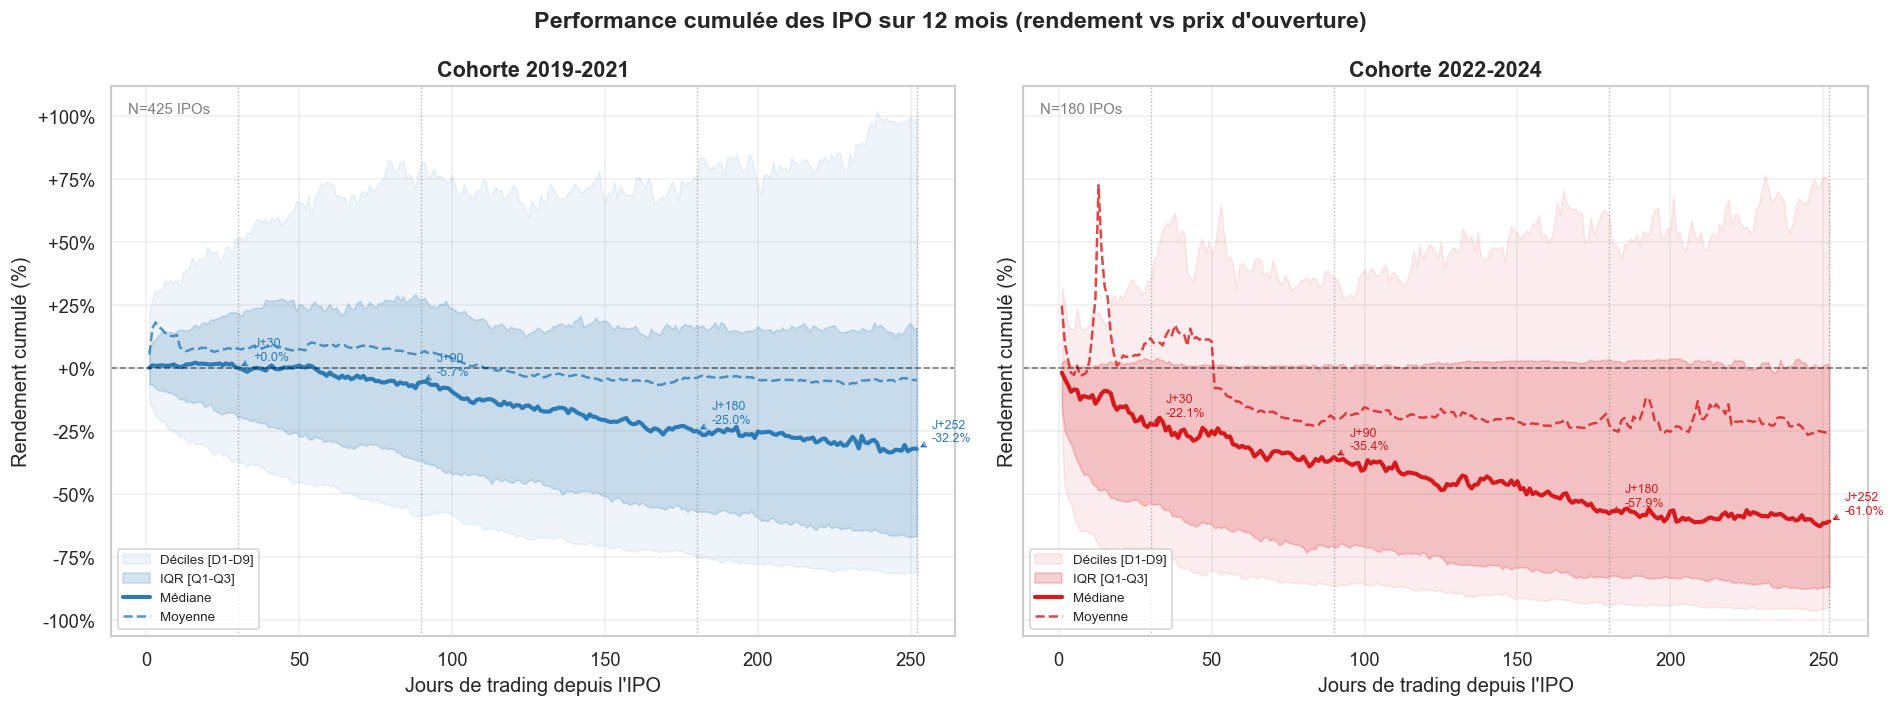

In [ ]:
# ── 4. Graphique 1 : Vue comparative côte à côte ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, cohort in zip(axes, ["2019-2021", "2022-2024"]):
    sub = agg[agg["cohort"] == cohort].copy()
    col = COLORS[cohort]

    # Bande Q10-Q90
    ax.fill_between(
        sub["trading_day"],
        sub["q10"] * 100,
        sub["q90"] * 100,
        color=col, alpha=0.08, label="Déciles [D1-D9]"
    )
    # Bande IQR Q25-Q75
    ax.fill_between(
        sub["trading_day"],
        sub["q25"] * 100,
        sub["q75"] * 100,
        color=col, alpha=0.20, label="IQR [Q1-Q3]"
    )
    # Médiane
    ax.plot(sub["trading_day"], sub["median"] * 100,
            color=col, lw=2.5, label="Médiane")
    # Moyenne (pointillé)
    ax.plot(sub["trading_day"], sub["mean"] * 100,
            color=col, lw=1.5, ls="--", alpha=0.8, label="Moyenne")

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_title(f"Cohorte {cohort}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Jours de trading depuis l'IPO")
    ax.set_ylabel("Rendement cumulé (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))

    # Annotations J=30, J=90, J=180, J=252
    for day, label in [(30, "J+30"), (90, "J+90"), (180, "J+180"), (252, "J+252")]:
        point = sub[sub["trading_day"] == day]
        if not point.empty:
            med_val = point["median"].values[0] * 100
            ax.axvline(day, color="gray", lw=0.8, ls=":", alpha=0.6)
            ax.annotate(f"{label}\n{med_val:+.1f}%",
                        xy=(day, med_val),
                        xytext=(day + 5, med_val + 3),
                        fontsize=7.5, color=col,
                        arrowprops=dict(arrowstyle="->", color=col, lw=0.8))

    n_start = sub[sub["trading_day"] == 1]["n_ipo"].values
    n_end   = sub[sub["trading_day"] == sub["trading_day"].max()]["n_ipo"].values
    n_start = n_start[0] if len(n_start) else "?"
    n_end   = n_end[0]   if len(n_end)   else "?"
    ax.text(0.02, 0.97, f"N={n_start} IPOs",
            transform=ax.transAxes, va="top", fontsize=9,
            color="gray")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Performance cumulée des IPO sur 12 mois (rendement vs prix d'ouverture)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("data/perf_12m_par_cohorte.png", dpi=150, bbox_inches="tight")
plt.show()

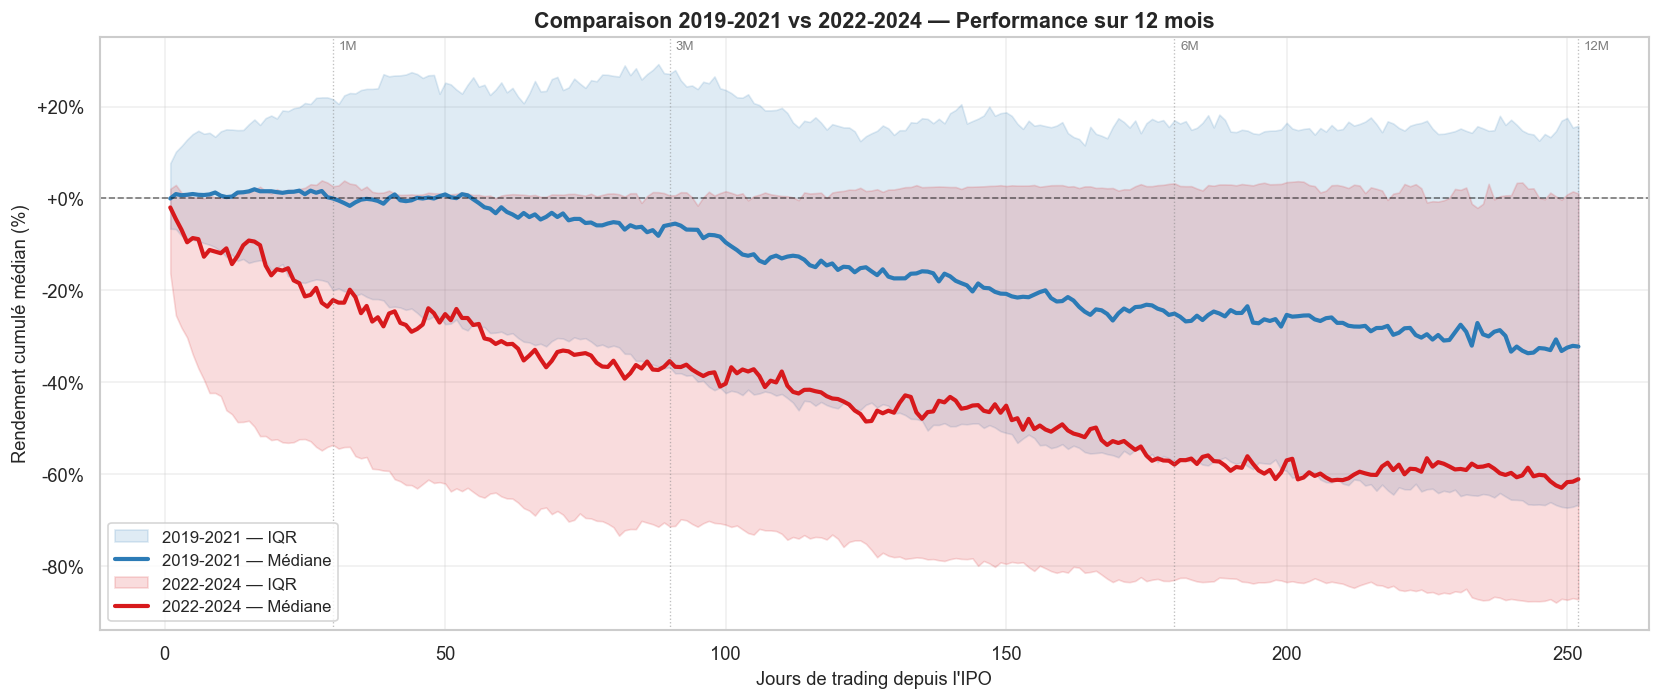

In [ ]:
# ── 5. Graphique 2 : Comparaison directe sur un seul axe ─────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for cohort in ["2019-2021", "2022-2024"]:
    sub = agg[agg["cohort"] == cohort].copy()
    col = COLORS[cohort]

    ax.fill_between(
        sub["trading_day"],
        sub["q25"] * 100,
        sub["q75"] * 100,
        color=col, alpha=0.15, label=f"{cohort} — IQR"
    )
    ax.plot(sub["trading_day"], sub["median"] * 100,
            color=col, lw=2.5, label=f"{cohort} — Médiane")

ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)

# Lignes verticales milestones
for day, label in [(30, "1M"), (90, "3M"), (180, "6M"), (252, "12M")]:
    ax.axvline(day, color="gray", lw=0.8, ls=":", alpha=0.5)
    ax.text(day + 1, ax.get_ylim()[1] * 0.98 if ax.get_ylim() else 5,
            label, fontsize=8, color="gray", va="top")

ax.set_xlabel("Jours de trading depuis l'IPO", fontsize=11)
ax.set_ylabel("Rendement cumulé médian (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
ax.set_title(
    "Comparaison 2019-2021 vs 2022-2024 — Performance sur 12 mois",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/perf_12m_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

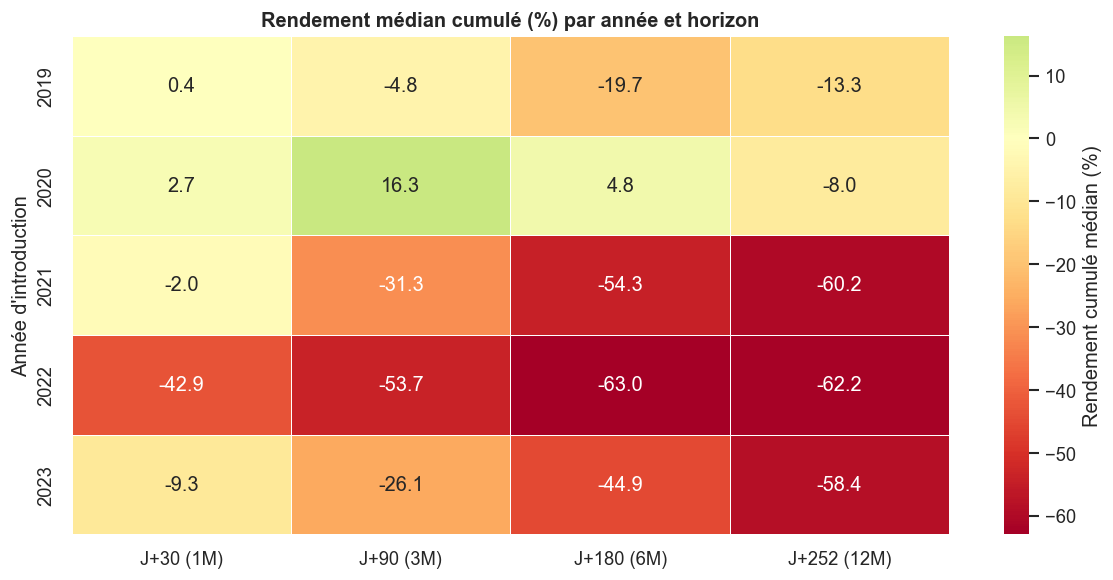


=== Tableau complet des rendements médians ===
Horizon  J+30 (1M)  J+90 (3M)  J+180 (6M)  J+252 (12M)
Année                                                 
2019         +0.4%      -4.8%      -19.7%       -13.3%
2020         +2.7%     +16.3%       +4.8%        -8.0%
2021         -2.0%     -31.3%      -54.3%       -60.2%
2022        -42.9%     -53.7%      -63.0%       -62.2%
2023         -9.3%     -26.1%      -44.9%       -58.4%


In [ ]:
# ── 6. Graphique 3 : Heatmap par année et mois de trading ─────────────────
# Rendement médian par année d'IPO à J=30, J=90, J=180, J=252

milestones = [30, 90, 180, 252]
labels = ["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]

rows = []
for year in sorted(df_daily["year"].unique()):
    for day, lbl in zip(milestones, labels):
        sub = df_daily[(df_daily["year"] == year) & (df_daily["trading_day"] == day)]
        if len(sub) > 0:
            rows.append({"Année": year, "Horizon": lbl,
                         "Médiane (%)": sub["cum_return"].median() * 100,
                         "N IPOs":      len(sub)})

df_heat = pd.DataFrame(rows)
pivot = df_heat.pivot(index="Année", columns="Horizon", values="Médiane (%)")
pivot = pivot[["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Rendement cumulé médian (%)"},
    ax=ax
)
ax.set_title("Rendement médian cumulé (%) par année et horizon",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Année d'introduction")
plt.tight_layout()
plt.savefig("data/perf_heatmap_annee.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Tableau complet des rendements médians ===")
print(pivot.to_string(float_format=lambda x: f"{x:+.1f}%"))

In [ ]:
# ── 7. Table de synthèse finale ────────────────────────────────────────────
print("=" * 65)
print("SYNTHÈSE — Rendements médians aux horizons clés")
print("=" * 65)

for cohort in ["2019-2021", "2022-2024"]:
    sub = agg[agg["cohort"] == cohort]
    print(f"\nCohorte {cohort} :")
    print(f"  {'Horizon':<12} {'Médiane':>10} {'Moyenne':>10} {'Q25':>10} {'Q75':>10} {'N':>6}")
    print(f"  {'-'*60}")
    for day, lbl in zip([30, 90, 180, 252], ["J+30 (1M)", "J+90 (3M)", "J+180 (6M)", "J+252 (12M)"]):
        row = sub[sub["trading_day"] == day]
        if not row.empty:
            r = row.iloc[0]
            print(f"  {lbl:<12} {r['median']*100:>+9.1f}% {r['mean']*100:>+9.1f}% "
                  f"{r['q25']*100:>+9.1f}% {r['q75']*100:>+9.1f}% {int(r['n_ipo']):>6}")

print("\n" + "=" * 65)

SYNTHÈSE — Rendements médians aux horizons clés

Cohorte 2019-2021 :
  Horizon         Médiane    Moyenne        Q25        Q75      N
  ------------------------------------------------------------
  J+30 (1M)         +0.0%      +7.6%     -20.0%     +21.6%    425
  J+90 (3M)         -5.7%      +6.0%     -36.7%     +27.1%    425
  J+180 (6M)       -25.0%      -4.1%     -57.1%     +17.0%    425
  J+252 (12M)      -32.2%      -4.9%     -66.6%     +15.8%    425

Cohorte 2022-2024 :
  Horizon         Médiane    Moyenne        Q25        Q75      N
  ------------------------------------------------------------
  J+30 (1M)        -22.1%     +11.7%     -53.6%      +2.7%    180
  J+90 (3M)        -35.4%     -20.2%     -71.3%      +0.7%    180
  J+180 (6M)       -57.9%     -22.6%     -83.0%      +3.3%    180
  J+252 (12M)      -61.0%     -25.8%     -87.2%      +1.1%    180



---
# Graphiques avec le taux de la Fed (Fed Funds Rate)

## Trois nouvelles visualisations
1. **Performance + Fed rate (axe secondaire)** : rendement cumulé médian et taux Fed sur le même graphique
2. **Scatter plot** : Fed rate à la date d'IPO vs rendement à 12 mois par IPO
3. **Carte thermique** : rendement médian par fourchette de taux Fed


In [ ]:
# ── Chargement du taux de la Fed (mensuel) ────────────────────────────────
df_fed_monthly = pd.read_excel("data/fred_monthly.xlsx")
df_fed_monthly["date"] = pd.to_datetime(df_fed_monthly["date"])
df_fed_monthly["year_month"] = df_fed_monthly["date"].dt.to_period("M").dt.to_timestamp()

df_fed_annual = pd.read_excel("data/fred_annual.xlsx")

# Ajouter year_month à df_daily pour le merge
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily["year_month"] = df_daily["date"].dt.to_period("M").dt.to_timestamp()

# Merge : chaque ligne de df_daily récupère le taux Fed du mois correspondant
df_daily_fed = df_daily.merge(
    df_fed_monthly[["year_month", "fed_rate"]],
    on="year_month",
    how="left"
)

# Agrégation par (cohorte, jour de trading) avec taux Fed médian
agg_fed = df_daily_fed.groupby(["cohort", "trading_day"]).agg(
    n_ipo=("cum_return", "count"),
    median_return=("cum_return", "median"),
    mean_return=("cum_return", "mean"),
    q25=("cum_return", lambda x: np.quantile(x, 0.25)),
    q75=("cum_return", lambda x: np.quantile(x, 0.75)),
    median_fed=("fed_rate", "median"),
    mean_fed=("fed_rate", "mean"),
).reset_index()

# Taux Fed à la date d'IPO (J=1 uniquement = premier jour de cotation)
df_ipo_fed = df_daily_fed[df_daily_fed["trading_day"] == 1][
    ["ticker", "cohort", "year", "fed_rate"]
].copy()

# Rendement à J=252 pour le scatter plot
df_ret_12m = df_daily_fed[df_daily_fed["trading_day"] == 252][
    ["ticker", "cum_return"]
].rename(columns={"cum_return": "ret_12m"})

df_scatter = df_ipo_fed.merge(df_ret_12m, on="ticker", how="inner")

print(f"Données préparées : {len(agg_fed)} lignes agrégées")
print(f"Scatter plot : {len(df_scatter)} IPOs avec taux Fed + rendement 12m")
print(f"\nTaux Fed moyen par cohorte (à la date d'IPO) :")
print(df_scatter.groupby("cohort")["fed_rate"].agg(["mean", "min", "max"]).round(2))


Données préparées : 504 lignes agrégées
Scatter plot : 605 IPOs avec taux Fed + rendement 12m

Taux Fed moyen par cohorte (à la date d'IPO) :
           mean   min   max
cohort                     
2019-2021  0.72  0.05  2.42
2022-2024  3.52  0.08  5.33


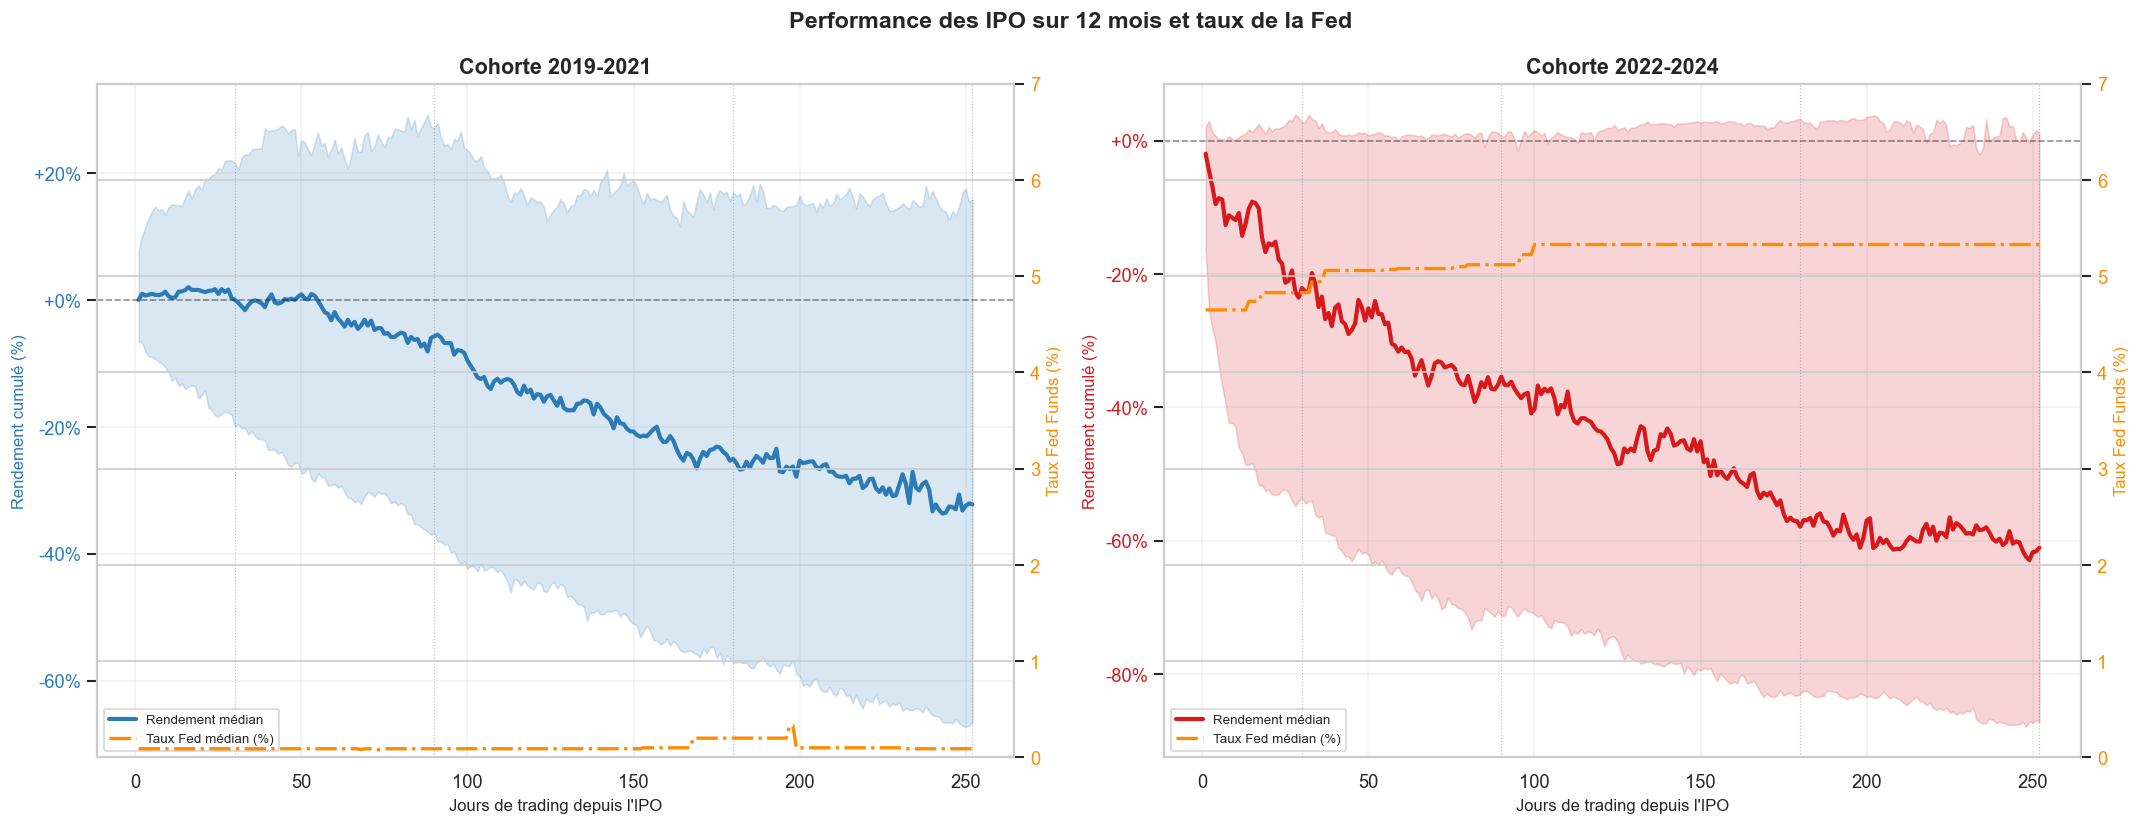

In [ ]:
# ── Graphique 1 : Performance cumulée + Taux Fed (axe secondaire) ─────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_main, cohort in zip(axes, ["2019-2021", "2022-2024"]):
    sub = agg_fed[agg_fed["cohort"] == cohort].copy()
    col = COLORS[cohort]

    # Axe gauche : rendement cumulé
    ax_main.fill_between(
        sub["trading_day"], sub["q25"]*100, sub["q75"]*100,
        color=col, alpha=0.18, label="IQR [Q1-Q3]"
    )
    l1, = ax_main.plot(
        sub["trading_day"], sub["median_return"]*100,
        color=col, lw=2.5, label="Rendement médian"
    )
    ax_main.axhline(0, color="black", lw=1, ls="--", alpha=0.4)
    ax_main.set_xlabel("Jours de trading depuis l'IPO", fontsize=10)
    ax_main.set_ylabel("Rendement cumulé (%)", color=col, fontsize=10)
    ax_main.tick_params(axis="y", labelcolor=col)
    ax_main.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f%%"))
    ax_main.set_title(f"Cohorte {cohort}", fontsize=13, fontweight="bold")

    for day in [30, 90, 180, 252]:
        ax_main.axvline(day, color="gray", lw=0.7, ls=":", alpha=0.5)

    # Axe droit : taux Fed
    ax_fed = ax_main.twinx()
    l2, = ax_fed.plot(
        sub["trading_day"], sub["median_fed"],
        color="#FF8C00", lw=2, ls="-.", label="Taux Fed médian (%)"
    )
    ax_fed.set_ylabel("Taux Fed Funds (%)", color="#FF8C00", fontsize=10)
    ax_fed.tick_params(axis="y", labelcolor="#FF8C00")
    ax_fed.set_ylim(0, 7)

    # Légende combinée
    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax_main.legend(lines, labels, loc="lower left", fontsize=8)
    ax_main.grid(True, alpha=0.25)

fig.suptitle(
    "Performance des IPO sur 12 mois et taux de la Fed",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("data/perf_12m_fed_cote_a_cote.png", dpi=150, bbox_inches="tight")
plt.show()


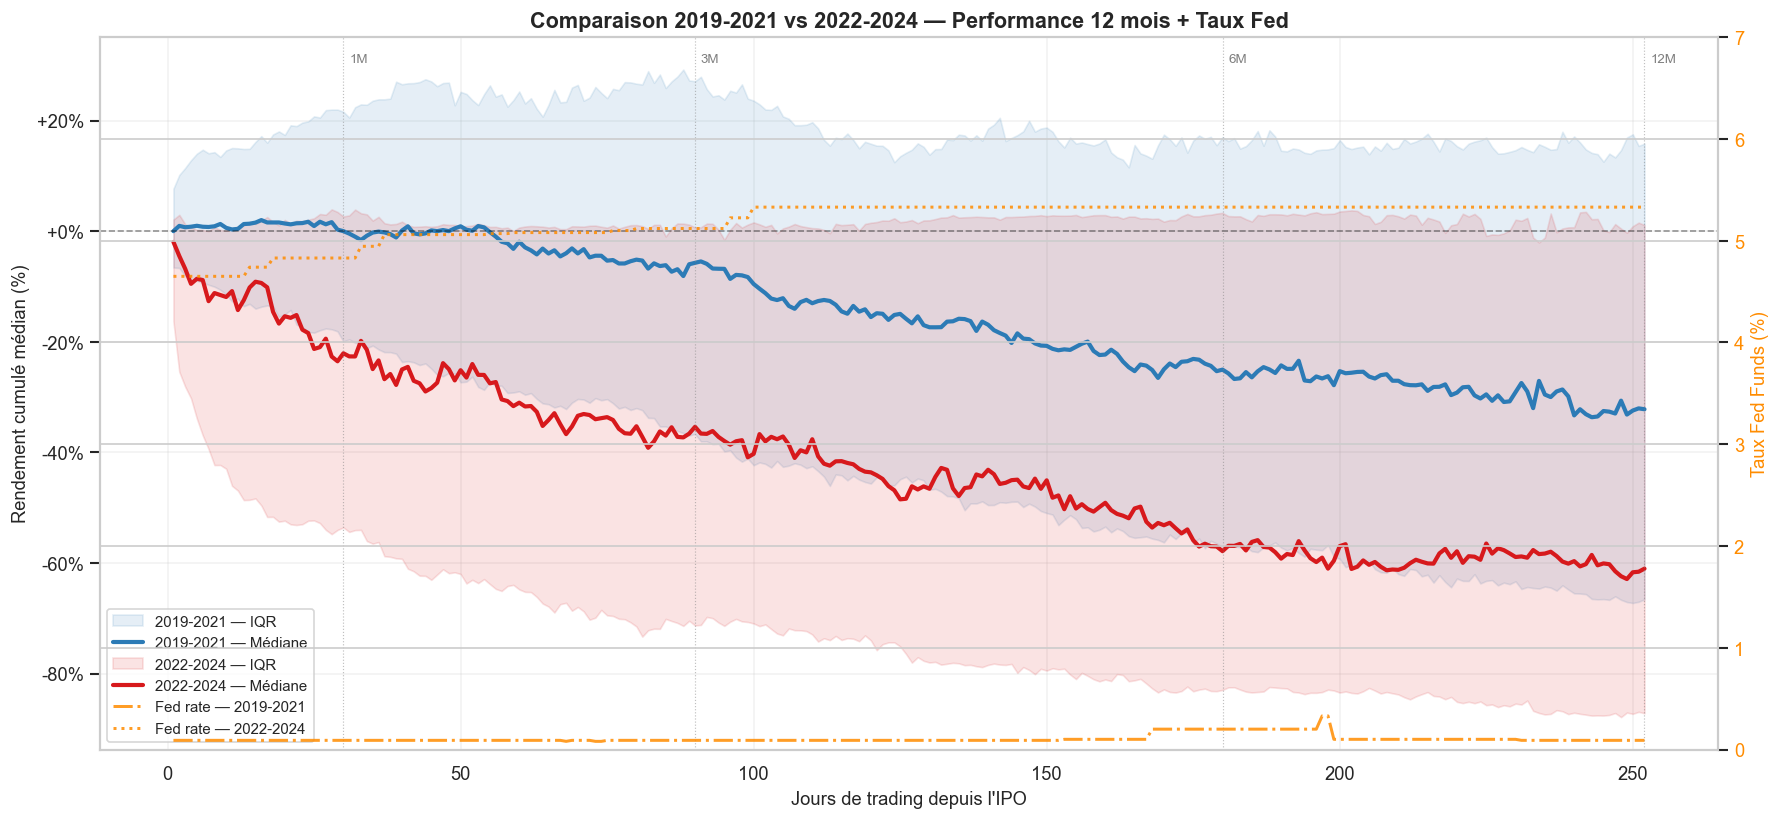

In [ ]:
# ── Graphique 2 : Comparaison directe 2019-2021 vs 2022-2024 + Taux Fed ───
fig, ax_main = plt.subplots(figsize=(15, 7))

for cohort in ["2019-2021", "2022-2024"]:
    sub = agg_fed[agg_fed["cohort"] == cohort]
    col = COLORS[cohort]
    ax_main.fill_between(
        sub["trading_day"], sub["q25"]*100, sub["q75"]*100,
        color=col, alpha=0.12, label=f"{cohort} — IQR"
    )
    ax_main.plot(
        sub["trading_day"], sub["median_return"]*100,
        color=col, lw=2.5, label=f"{cohort} — Médiane"
    )

ax_main.axhline(0, color="black", lw=1, ls="--", alpha=0.4)
ax_main.set_xlabel("Jours de trading depuis l'IPO", fontsize=11)
ax_main.set_ylabel("Rendement cumulé médian (%)", fontsize=11)
ax_main.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f%%"))

for day, lbl in [(30,"1M"),(90,"3M"),(180,"6M"),(252,"12M")]:
    ax_main.axvline(day, color="gray", lw=0.7, ls=":", alpha=0.5)
    ax_main.text(day+1, ax_main.get_ylim()[1]*0.92 if ax_main.get_ylim()[1]>0 else 5,
                 lbl, fontsize=8, color="gray", va="top")

# Axe droit Fed rate (les deux cohortes)
ax_fed = ax_main.twinx()
for cohort, ls in [("2019-2021", "-."), ("2022-2024", ":")]:
    sub = agg_fed[agg_fed["cohort"] == cohort]
    ax_fed.plot(
        sub["trading_day"], sub["median_fed"],
        color="#FF8C00", lw=1.8, ls=ls, alpha=0.85,
        label=f"Fed rate — {cohort}"
    )

ax_fed.set_ylabel("Taux Fed Funds (%)", color="#FF8C00", fontsize=11)
ax_fed.tick_params(axis="y", labelcolor="#FF8C00")
ax_fed.set_ylim(0, 7)

# Légendes
lines_main, labels_main = ax_main.get_legend_handles_labels()
lines_fed, labels_fed = ax_fed.get_legend_handles_labels()
ax_main.legend(lines_main + lines_fed, labels_main + labels_fed,
               loc="lower left", fontsize=9)

ax_main.set_title(
    "Comparaison 2019-2021 vs 2022-2024 — Performance 12 mois + Taux Fed",
    fontsize=13, fontweight="bold"
)
ax_main.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("data/perf_12m_fed_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()


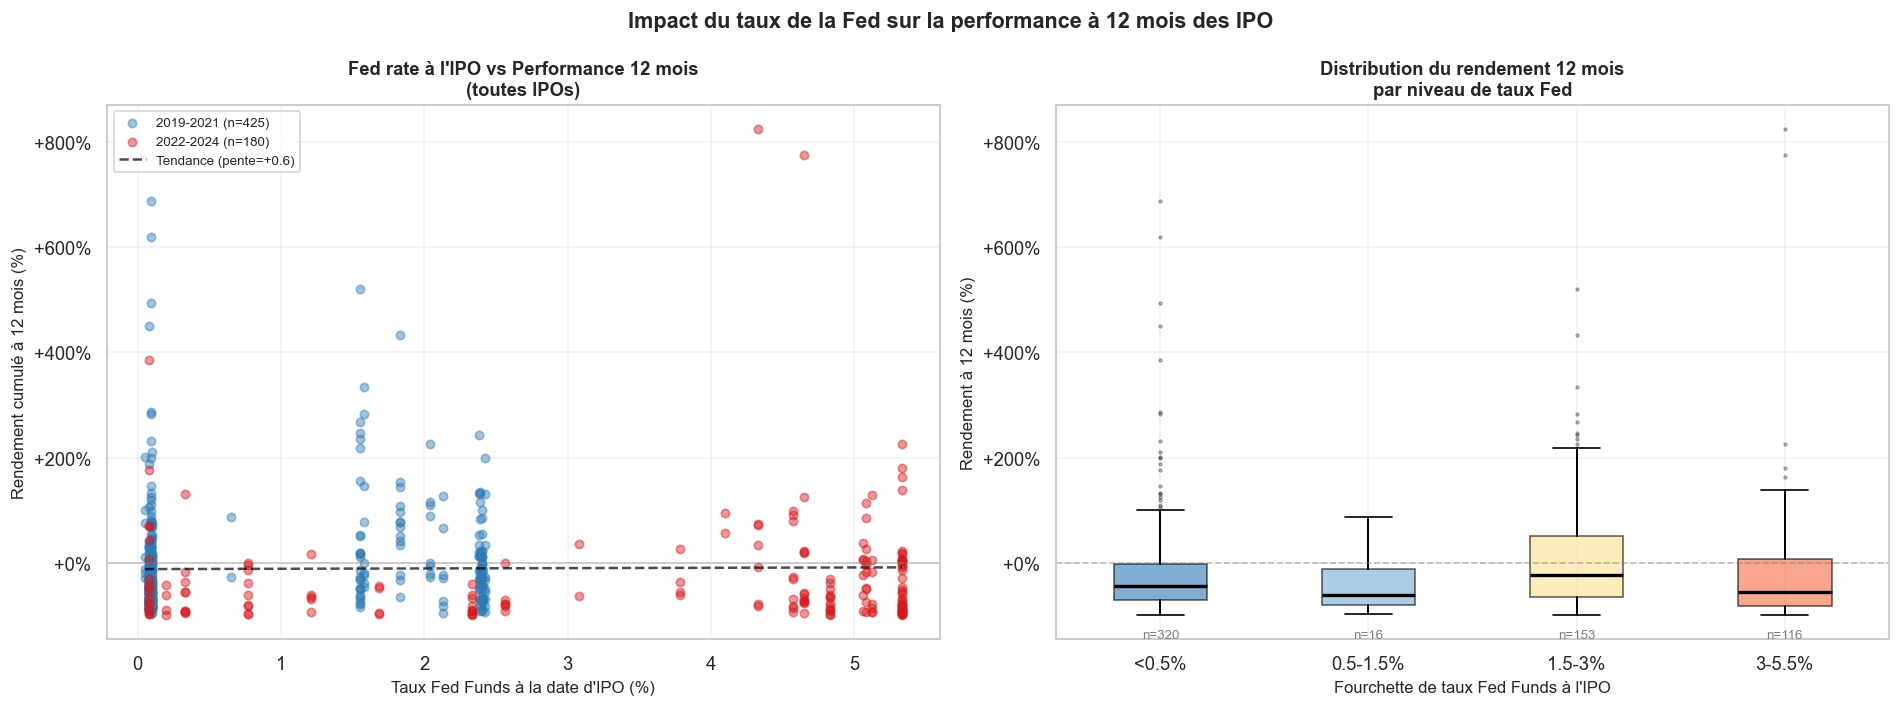

In [ ]:
# ── Graphique 3 : Scatter — Taux Fed à l'IPO vs Rendement à 12 mois ───────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 3a : Scatter brut (toutes IPOs) ──
ax = axes[0]
for cohort in ["2019-2021", "2022-2024"]:
    sub = df_scatter[df_scatter["cohort"] == cohort]
    ax.scatter(
        sub["fed_rate"],
        sub["ret_12m"] * 100,
        color=COLORS[cohort],
        alpha=0.45,
        s=25,
        label=f"{cohort} (n={len(sub)})",
    )

# Ligne de tendance générale
from numpy.polynomial.polynomial import polyfit
x_all = df_scatter["fed_rate"].values
y_all = df_scatter["ret_12m"].values * 100
mask = np.isfinite(x_all) & np.isfinite(y_all)
if mask.sum() > 2:
    coef = np.polyfit(x_all[mask], y_all[mask], 1)
    x_line = np.linspace(x_all[mask].min(), x_all[mask].max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line),
            color="black", lw=1.5, ls="--", label=f"Tendance (pente={coef[0]:+.1f})", alpha=0.7)

ax.axhline(0, color="gray", lw=1, ls="-", alpha=0.4)
ax.set_xlabel("Taux Fed Funds à la date d'IPO (%)", fontsize=10)
ax.set_ylabel("Rendement cumulé à 12 mois (%)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f%%"))
ax.set_title("Fed rate à l'IPO vs Performance 12 mois\n(toutes IPOs)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── 3b : Boxplot par fourchette de taux ──
ax = axes[1]
bins_fed = [0, 0.5, 1.5, 3.0, 5.5, 8.0]
labels_bins = ["<0.5%", "0.5-1.5%", "1.5-3%", "3-5.5%", ">5.5%"]
df_scatter["fed_bin"] = pd.cut(
    df_scatter["fed_rate"], bins=bins_fed, labels=labels_bins, right=True
)

# Couleur par cohorte dominante dans chaque bin
bin_data = [
    df_scatter[df_scatter["fed_bin"] == lbl]["ret_12m"].dropna() * 100
    for lbl in labels_bins
]
bp = ax.boxplot(
    [d for d in bin_data if len(d) > 0],
    labels=[lbl for lbl, d in zip(labels_bins, bin_data) if len(d) > 0],
    patch_artist=True,
    medianprops=dict(color="black", lw=2),
    whiskerprops=dict(lw=1.2),
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
)

fed_colors = ["#2C7BB6", "#74ADD1", "#FEE090", "#F46D43", "#D73027"]
for patch, fcolor in zip(bp["boxes"], fed_colors):
    patch.set_facecolor(fcolor)
    patch.set_alpha(0.6)

ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Fourchette de taux Fed Funds à l'IPO", fontsize=10)
ax.set_ylabel("Rendement à 12 mois (%)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f%%"))
ax.set_title("Distribution du rendement 12 mois\npar niveau de taux Fed",
             fontsize=11, fontweight="bold")

# Annotations : N et médiane
for i, d in enumerate([d for d in bin_data if len(d) > 0]):
    ax.text(i + 1, ax.get_ylim()[0] + 2, f"n={len(d)}",
            ha="center", fontsize=8, color="gray")

ax.grid(True, alpha=0.25)

fig.suptitle(
    "Impact du taux de la Fed sur la performance à 12 mois des IPO",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("data/perf_12m_fed_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


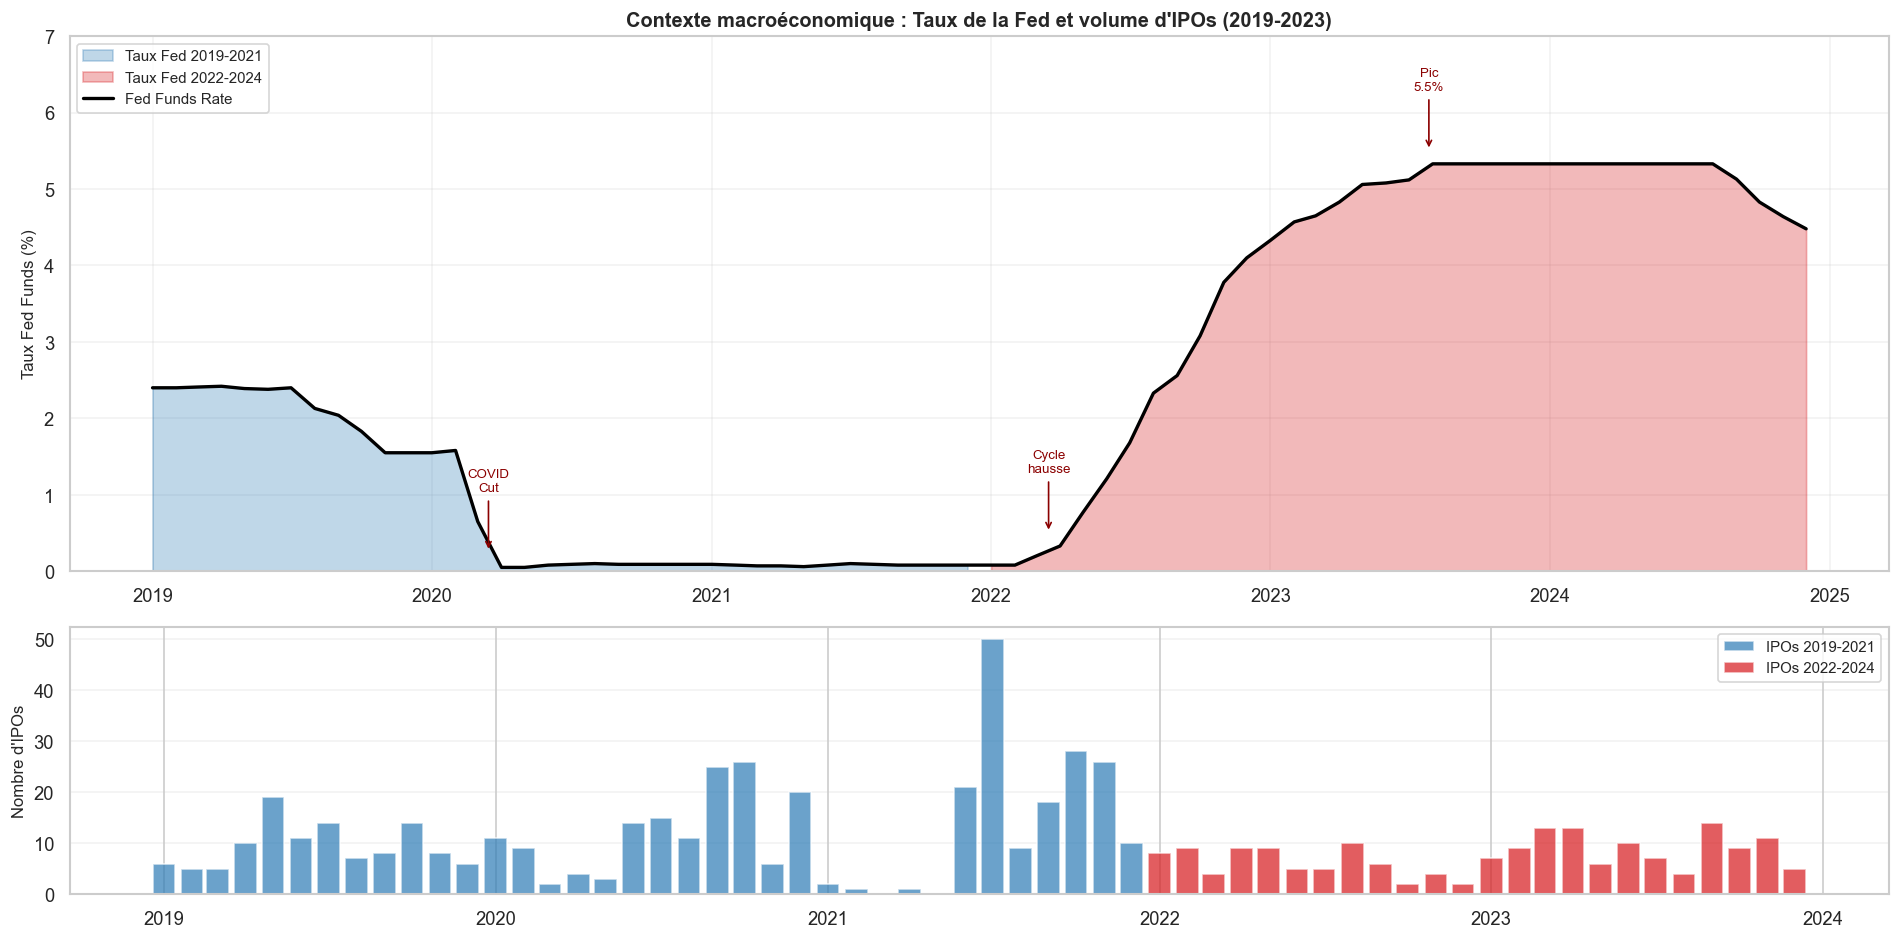

Tous les graphiques Fed rate ont été sauvegardés dans data/


In [ ]:
# ── Graphique 4 : Timeline Fed rate + volume d'IPOs par mois ──────────────
# Préparer : nombre d'IPOs par mois (depuis df_base)
df_base_plot = pd.read_excel("data/yfinance_prices.xlsx")
df_base_plot["ipo_date"] = pd.to_datetime(df_base_plot["ipo_date"])
df_base_plot = df_base_plot[df_base_plot["year"].between(2019, 2023)].copy()
df_base_plot["year_month"] = df_base_plot["ipo_date"].dt.to_period("M").dt.to_timestamp()
df_base_plot["cohort"] = np.where(df_base_plot["year"].between(2019, 2021), "2019-2021", "2022-2024")

ipo_monthly = df_base_plot.groupby(["year_month", "cohort"]).size().reset_index(name="n_ipo")

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 8),
                                      gridspec_kw={"height_ratios": [2, 1]},
                                      sharex=False)

# ── Panneau haut : Fed rate ──
fed = df_fed_monthly.copy()
fed_19_20 = fed[(fed["date"] >= "2019-01-01") & (fed["date"] <= "2021-12-31")]
fed_21_23 = fed[(fed["date"] >= "2022-01-01") & (fed["date"] <= "2024-12-31")]

ax_top.fill_between(fed_19_20["date"], fed_19_20["fed_rate"],
                    color=COLORS["2019-2021"], alpha=0.3, label="Taux Fed 2019-2021")
ax_top.fill_between(fed_21_23["date"], fed_21_23["fed_rate"],
                    color=COLORS["2022-2024"], alpha=0.3, label="Taux Fed 2022-2024")
ax_top.plot(fed["date"], fed["fed_rate"], color="black", lw=2, label="Fed Funds Rate")

# Annotations clés
events = [
    ("2020-03-15", 0.25, "COVID\nCut"),
    ("2022-03-17", 0.5,  "Cycle\nhausse"),
    ("2023-07-27", 5.5,  "Pic\n5.5%"),
]
for date_str, y_val, label in events:
    ax_top.annotate(label,
                    xy=(pd.to_datetime(date_str), y_val),
                    xytext=(pd.to_datetime(date_str), y_val + 0.8),
                    fontsize=8, ha="center", color="darkred",
                    arrowprops=dict(arrowstyle="->", color="darkred", lw=1))

ax_top.set_ylabel("Taux Fed Funds (%)", fontsize=10)
ax_top.set_ylim(0, 7)
ax_top.legend(fontsize=9, loc="upper left")
ax_top.grid(True, alpha=0.25)
ax_top.set_title("Contexte macroéconomique : Taux de la Fed et volume d'IPOs (2019-2023)",
                 fontsize=12, fontweight="bold")

# ── Panneau bas : volume d'IPOs par mois ──
for cohort in ["2019-2021", "2022-2024"]:
    sub = ipo_monthly[ipo_monthly["cohort"] == cohort]
    ax_bot.bar(sub["year_month"], sub["n_ipo"],
               color=COLORS[cohort], alpha=0.7, width=25,
               label=f"IPOs {cohort}")

ax_bot.set_ylabel("Nombre d'IPOs", fontsize=10)
ax_bot.legend(fontsize=9)
ax_bot.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("data/perf_12m_fed_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

print("Tous les graphiques Fed rate ont été sauvegardés dans data/")
